# 05 Spatial Operations: Clip, Mask, and Reproject
**Tutorial:** Building Geospatial Data Cubes for Earth Data Science  
**Focus:** Pine Ridge (Oglala Lakota Nation), South Dakota  
**Prerequisites:** Notebooks 00–04  

## What This Notebook Covers
Notebooks 02–04 built a cube from point data using a single location at
the center of Pine Ridge. Real geospatial data cubes are spatial in that
they cover a geographic area, with each pixel representing a different
location on the ground.

This notebook introduces `rioxarray`, which extends xarray with geospatial
capabilities. You will learn to:

1. Work with raster data that has real spatial coordinates
2. Assign a Coordinate Reference System (CRS) to a cube
3. **Clip** a cube to a boundary polygon (the full Pine Ridge Reservation)
4. **Mask** pixels outside the boundary
5. **Reproject** between coordinate systems
6. Compare spatial patterns across the reservation

## What Is rioxarray?
rioxarray is an extension for xarray that adds geospatial operations through
a `.rio` accessor. Instead of writing `da.something()`, you write
`da.rio.something()`. The `.rio` part tells xarray to use the geospatial
version of that operation.

## Data Approach
We construct a spatial NDVI cube by fetching MODIS NDVI time series for
a grid of points covering Pine Ridge, then assembling them into a 3D
(lat × lon × time) DataArray. This approach uses the same ORNL DAAC API
as previous notebooks, no raster file downloads required.

In [28]:
# Imports
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import warnings
import time
import datetime

import numpy as np
import pandas as pd
import xarray as xr
import rioxarray          
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import contextily as ctx
from shapely.geometry import Point

from src.cube_utils import (
    load_pine_ridge_boundary,
    load_sd_tribal_boundaries,
    fetch_ndvi_timeseries,
    timeseries_to_dataarray,
    compute_growing_season_mean,
    CACHE_DIR,
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
%matplotlib inline

GROWING_MONTHS = [5, 6, 7, 8, 9]
START_YEAR     = 2000
END_YEAR       = 2023

def despine(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

print("rioxarray version:", rioxarray.__version__)
print("Setup complete.")

rioxarray version: 0.19.0
Setup complete.


## Understanding CRS
Before doing any spatial operations, we need to understand Coordinate
Reference Systems. A CRS defines how the numbers in your data map to
real locations on Earth.

In [29]:
# Load Pine Ridge boundary
pine_ridge = load_pine_ridge_boundary()

print("Pine Ridge boundary CRS:")
print(f"  {pine_ridge.crs}")
print(f"  EPSG code: {pine_ridge.crs.to_epsg()}")
print()
print("Coordinates in EPSG:4326 (geographic: degrees):")
bounds = pine_ridge.total_bounds
print(f"  West : {bounds[0]:.4f}°")
print(f"  South: {bounds[1]:.4f}°")
print(f"  East : {bounds[2]:.4f}°")
print(f"  North: {bounds[3]:.4f}°")

# Reproject to EPSG:5070 (Albers Equal Area is good for area calculations)
pine_ridge_proj = pine_ridge.to_crs("EPSG:5070")
print()
print("Same boundary in EPSG:5070 (projected: meters):")
bounds_proj = pine_ridge_proj.total_bounds
print(f"  West : {bounds_proj[0]:,.0f} m")
print(f"  South: {bounds_proj[1]:,.0f} m")
print(f"  East : {bounds_proj[2]:,.0f} m")
print(f"  North: {bounds_proj[3]:,.0f} m")
print()
area_km2 = pine_ridge_proj.geometry.area.sum() / 1e6
print(f"Area: {area_km2:,.0f} km²  (computed in projected CRS; this is accurate)")

Pine Ridge boundary CRS:
  EPSG:4326
  EPSG code: 4326

Coordinates in EPSG:4326 (geographic: degrees):
  West : -103.0010°
  South: 42.9874°
  East : -101.2273°
  North: 43.7967°

Same boundary in EPSG:5070 (projected: meters):
  West : -567,159 m
  South: 2,234,116 m
  East : -418,815 m
  North: 2,323,805 m

Area: 11,275 km²  (computed in projected CRS; this is accurate)


## Build a Spatial NDVI Grid
We create a coarse grid of points covering Pine Ridge and fetch NDVI
for each point, then assemble them into a 3D spatial cube.

In [30]:
# Define a coarse grid over Pine Ridge
# Pine Ridge bounding box: ~43°–44°N, ~103°–101.5°W
# We use a 0.5° grid (about 35km spacing) to keep downloads manageable
# For a finer grid, reduce the step size (but downloads will be slower)

 # Coarse grid, but fast for this tutorial; change GRID_STEP to change the grid
GRID_STEP = 0.5  

LAT_MIN, LAT_MAX = 43.0, 44.0
LON_MIN, LON_MAX = -103.0, -101.5

grid_lats = np.arange(LAT_MIN, LAT_MAX + GRID_STEP, GRID_STEP)
grid_lons = np.arange(LON_MIN, LON_MAX + GRID_STEP, GRID_STEP)

print(f"Grid: {len(grid_lats)} latitudes × {len(grid_lons)} longitudes")
print(f"Grid lats: {grid_lats}")
print(f"Grid lons: {grid_lons}")
print(f"Total points: {len(grid_lats) * len(grid_lons)}")
print(f"Grid spacing: ~{GRID_STEP * 111:.0f} km")

Grid: 3 latitudes × 4 longitudes
Grid lats: [43.  43.5 44. ]
Grid lons: [-103.  -102.5 -102.  -101.5]
Total points: 12
Grid spacing: ~56 km


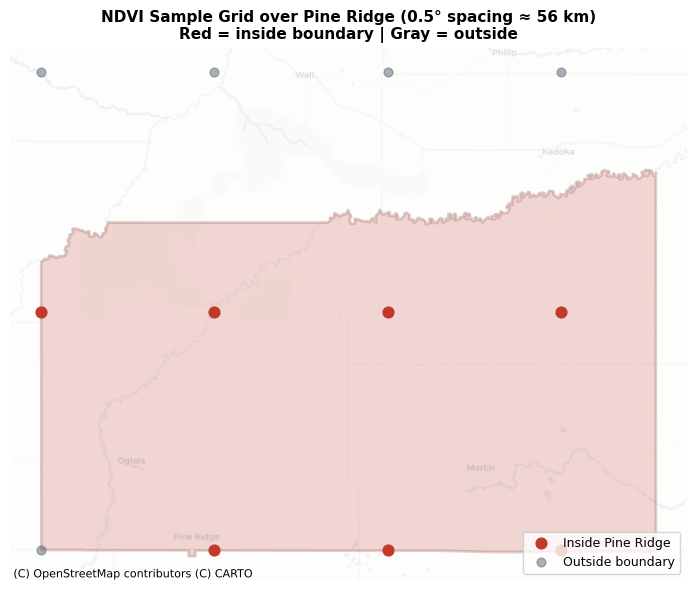

Grid points inside Pine Ridge boundary: 7
We will fetch NDVI for all 12 points then mask to boundary.


In [31]:
# Map the grid overlaid on Pine Ridge boundary
fig, ax = plt.subplots(figsize=(10, 6))

pine_ridge.to_crs(3857).plot(
    ax=ax, facecolor="#C0392B", alpha=0.2,
    edgecolor="#7B241C", linewidth=2,
)

# Plot grid points
grid_points = [
    Point(lon, lat)
    for lat in grid_lats
    for lon in grid_lons
]
grid_gdf = gpd.GeoDataFrame(
    geometry=grid_points, crs="EPSG:4326"
).to_crs(3857)

# Color points inside vs outside Pine Ridge
inside = gpd.sjoin(
    grid_gdf,
    pine_ridge.to_crs(3857)[["geometry"]],
    how="left", predicate="within"
)
inside_mask = inside["index_right"].notna()

grid_gdf[inside_mask].plot(
    ax=ax, color="#C0392B", markersize=60, marker="o",
    zorder=5, label="Inside Pine Ridge",
)
grid_gdf[~inside_mask].plot(
    ax=ax, color="#566573", markersize=40, marker="o",
    zorder=4, alpha=0.5, label="Outside boundary",
)

try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, alpha=0.4)
except Exception:
    pass

ax.set_axis_off()
ax.legend(fontsize=9, loc="lower right")
ax.set_title(
    f"NDVI Sample Grid over Pine Ridge ({GRID_STEP}° spacing ≈ {GRID_STEP*111:.0f} km)\n"
    "Red = inside boundary | Gray = outside",
    fontsize=11, fontweight="bold",
)
plt.tight_layout()
plt.show()

n_inside = inside_mask.sum()
print(f"Grid points inside Pine Ridge boundary: {n_inside}")
print(f"We will fetch NDVI for all {len(grid_points)} points then mask to boundary.")

In [32]:
# Fetch NDVI for all grid points
# Each point fetches one year at a time via ORNL DAAC API
# Cached after first run

# We use annual growing season means to keep the cube manageable
CACHE_KEY = f"spatial_grid_{GRID_STEP}deg_{START_YEAR}_{END_YEAR}"
spatial_cache = CACHE_DIR/f"{CACHE_KEY}.nc"

if spatial_cache.exists():
    spatial_cube = xr.open_dataset(spatial_cache)
    print(f"Spatial cube loaded from cache: {spatial_cache.name}")
    print(spatial_cube)
else:
    print(f"Building spatial NDVI cube ({len(grid_lats)}×{len(grid_lons)} grid)...")
    print("First run: allow several  minutes depending on grid size.")

    # Store annual growing season mean for each grid point
    grid_data = np.full(
        (len(range(START_YEAR, END_YEAR + 1)), len(grid_lats), len(grid_lons)),
        np.nan
    )
    years = np.arange(START_YEAR, END_YEAR + 1)

    for i, lat in enumerate(grid_lats):
        for j, lon in enumerate(grid_lons):
            site = f"grid_{lat:.2f}_{lon:.2f}"
            try:
                df = fetch_ndvi_timeseries(
                    lat=lat, lon=lon,
                    start_year=START_YEAR,
                    end_year=END_YEAR,
                    site_name=site,
                )
                da      = timeseries_to_dataarray(df, name="ndvi")
                annual  = compute_growing_season_mean(da, months=GROWING_MONTHS)
                # Align annual values to our years array
                for k, yr in enumerate(years):
                    yr_vals = annual.sel(year=yr, method="nearest")
                    grid_data[k, i, j] = float(yr_vals)
                print(f"  ({lat:.1f}, {lon:.1f}): {len(df)} obs")
            except Exception as e:
                print(f"  ({lat:.1f}, {lon:.1f}): failed {e}")

    spatial_cube = xr.Dataset(
        data_vars={
            "ndvi": xr.DataArray(
                data   = grid_data,
                coords = {"year": years, "lat": grid_lats, "lon": grid_lons},
                dims   = ["year", "lat", "lon"],
                attrs  = {
                    "long_name": "Annual growing season mean NDVI",
                    "units":     "dimensionless",
                    "source":    "MODIS MOD13Q1 via ORNL DAAC",
                },
            )
        },
        attrs={
            "title":        "Pine Ridge Spatial NDVI Cube",
            "location":     "Pine Ridge, Oglala Lakota Nation",
            "grid_step_deg": GRID_STEP,
            "tk_community": "Oglala Lakota Nation",
        }
    )
    spatial_cube.to_netcdf(spatial_cache)
    print(f"\nSpatial cube saved: {spatial_cache.name}")

Spatial cube loaded from cache: spatial_grid_0.5deg_2000_2023.nc
<xarray.Dataset> Size: 3kB
Dimensions:  (year: 24, lat: 3, lon: 4)
Coordinates:
  * year     (year) int64 192B 2000 2001 2002 2003 2004 ... 2020 2021 2022 2023
  * lat      (lat) float64 24B 43.0 43.5 44.0
  * lon      (lon) float64 32B -103.0 -102.5 -102.0 -101.5
Data variables:
    ndvi     (year, lat, lon) float64 2kB ...
Attributes:
    title:          Pine Ridge Spatial NDVI Cube
    location:       Pine Ridge, Oglala Lakota Nation
    grid_step_deg:  0.5
    tk_community:   Oglala Lakota Nation


## Assign CRS and Use rioxarray

In [33]:
# Assign CRS to the spatial cube using rioxarray
# The .rio accessor is activated by importing rioxarray in the imports cell

ndvi_spatial = spatial_cube["ndvi"]

# Tell rioxarray which dimensions are spatial
ndvi_spatial = ndvi_spatial.rio.set_spatial_dims(
    x_dim="lon", y_dim="lat"
)

# Write the CRS (our data is in WGS84 geographic coordinates)
ndvi_spatial = ndvi_spatial.rio.write_crs("EPSG:4326")

print("CRS assigned:")
print(f"  {ndvi_spatial.rio.crs}")
print(f"  Resolution: {ndvi_spatial.rio.resolution()}")
print(f"  Bounds: {ndvi_spatial.rio.bounds()}")
print(f"  Shape: {ndvi_spatial.shape}  (year × lat × lon)")

CRS assigned:
  EPSG:4326
  Resolution: (0.5, 0.5)
  Bounds: (-103.25, 42.75, -101.25, 44.25)
  Shape: (24, 3, 4)  (year × lat × lon)


## Clip to the Tribal Boundary
Clipping cuts a raster dataset to a bounding box or polygon.
Masking sets pixels outside the polygon to NaN.

Total grid points: 12
Inside Pine Ridge: 7
Outside:           5


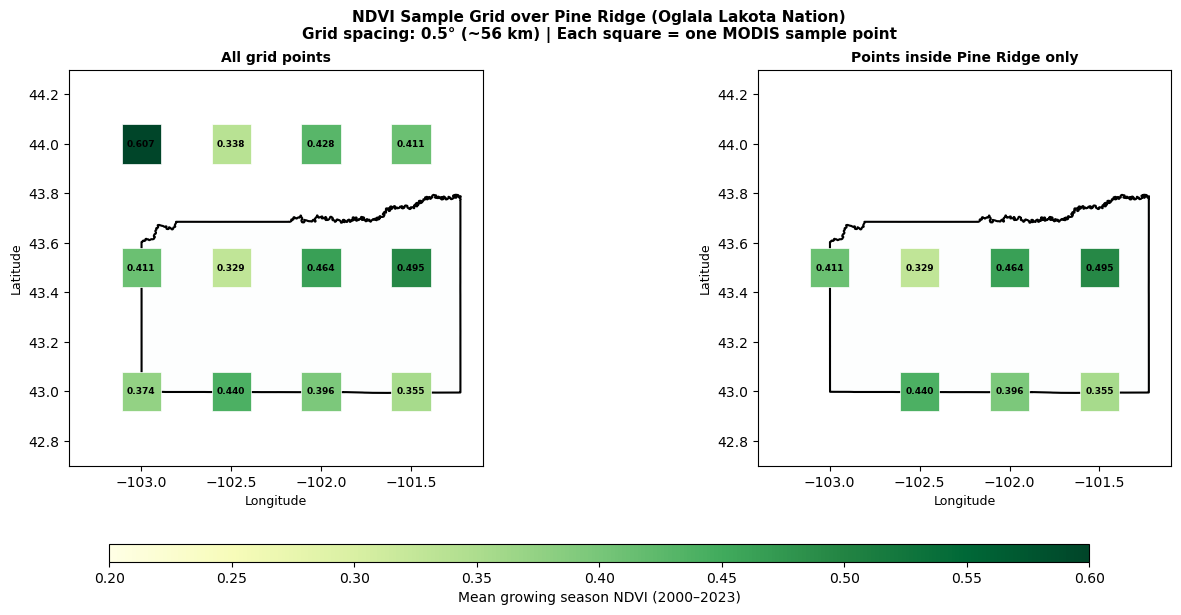


NOTE: The coarse grid shows sample points, not a filled raster.
To fill the reservation continuously, reduce GRID_STEP to 0.1° or less.
At 0.1° spacing you would have ~150 points
covering the same area with download time ~450 API calls.


In [34]:
ndvi_mean = ndvi_spatial.mean(dim="year")

# Build GeoDataFrame of grid points with NDVI values 
point_records = []
for i, lat in enumerate(grid_lats):
    for j, lon in enumerate(grid_lons):
        point_records.append({
            "lat":  lat,
            "lon":  lon,
            "ndvi": float(ndvi_mean.values[i, j]),
            "geometry": Point(lon, lat),
        })

points_gdf = gpd.GeoDataFrame(point_records, crs="EPSG:4326")

# Mark points inside Pine Ridge boundary
inside_join = gpd.sjoin(
    points_gdf,
    pine_ridge[["geometry"]],
    how="left", predicate="intersects",
)
points_gdf["inside"] = inside_join["index_right"].notna().values

print(f"Total grid points: {len(points_gdf)}")
print(f"Inside Pine Ridge: {points_gdf['inside'].sum()}")
print(f"Outside:           {(~points_gdf['inside']).sum()}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

norm = plt.Normalize(vmin=0.2, vmax=0.6)
cmap = plt.cm.YlGn

for ax, mask, title in [
    (axes[0], slice(None),              "All grid points"),
    (axes[1], points_gdf["inside"],     "Points inside Pine Ridge only"),
]:
    subset = points_gdf[mask] if isinstance(mask, pd.Series) else points_gdf

    pine_ridge.plot(
        ax=ax, facecolor="#FDFEFE", edgecolor="black",
        linewidth=1.5, zorder=1,
    )
    sc = ax.scatter(
        subset["lon"], subset["lat"],
        c=subset["ndvi"], cmap=cmap, norm=norm,
        s=800, marker="s", zorder=3,
        edgecolors="white", linewidths=0.5,
    )
    # Label each point with its NDVI value
    for _, row in subset.iterrows():
        ax.annotate(
            f"{row['ndvi']:.3f}",
            (row["lon"], row["lat"]),
            ha="center", va="center",
            fontsize=6.5, fontweight="bold", color="black", zorder=4,
        )

    ax.set_xlim(points_gdf["lon"].min() - 0.4, points_gdf["lon"].max() + 0.4)
    ax.set_ylim(points_gdf["lat"].min() - 0.3, points_gdf["lat"].max() + 0.3)
    ax.set_title(title, fontweight="bold", fontsize=10)
    ax.set_xlabel("Longitude", fontsize=9)
    ax.set_ylabel("Latitude", fontsize=9)

fig.subplots_adjust(bottom=0.22, top=0.88, left=0.08, right=0.95, wspace=0.3)
cbar_ax = fig.add_axes([0.15, 0.06, 0.7, 0.03])
fig.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap),
    cax=cbar_ax,
    orientation="horizontal",
    label="Mean growing season NDVI (2000–2023)",
)
plt.suptitle(
    "NDVI Sample Grid over Pine Ridge (Oglala Lakota Nation)\n"
    f"Grid spacing: {GRID_STEP}° (~{GRID_STEP*111:.0f} km) | "
    "Each square = one MODIS sample point",
    fontsize=11, fontweight="bold",
)
plt.show()

print()
print("NOTE: The coarse grid shows sample points, not a filled raster.")
print(f"To fill the reservation continuously, reduce GRID_STEP to 0.1° or less.")
print(f"At 0.1° spacing you would have ~{int((1.5/0.1) * (1.0/0.1))} points")
print(f"covering the same area with download time ~{int((1.5/0.1) * (1.0/0.1)) * 3} API calls.")

## Spatial Patterns Within the Reservation
Even at coarse resolution, we can ask: are some parts of Pine Ridge
consistently greener than others? Do the same areas suffer most in drought years?

Best year  (highest mean NDVI): 2019
Worst year (lowest mean NDVI) : 2012


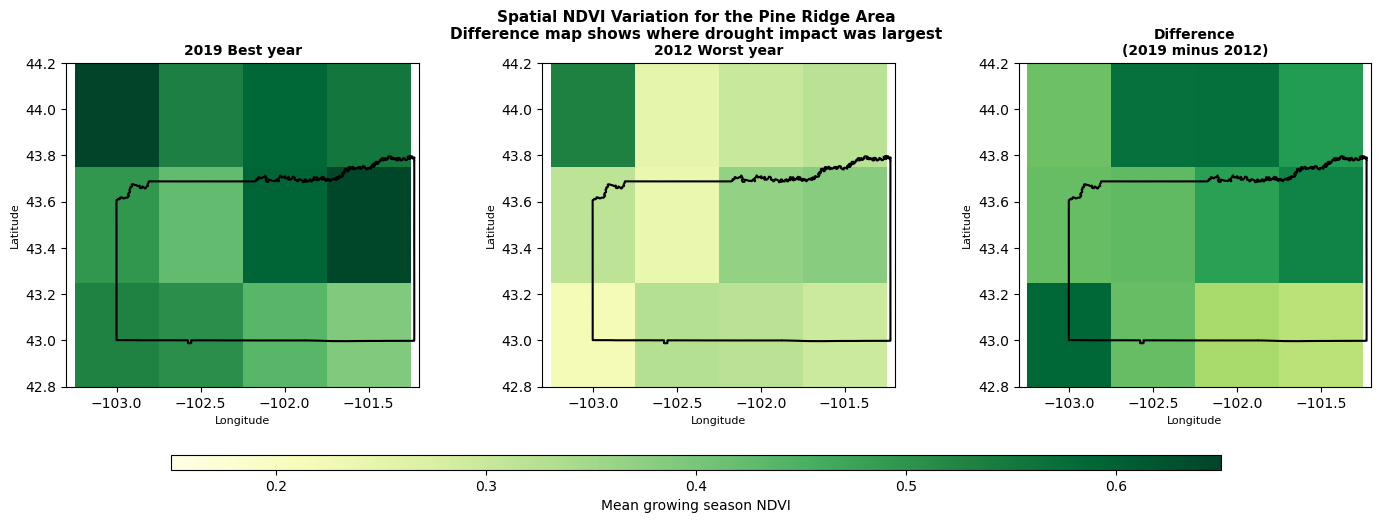

In [35]:
# Best vs worst year comparison
annual_spatial_mean = ndvi_spatial.mean(dim=["lat", "lon"])
best_year  = int(annual_spatial_mean.year[annual_spatial_mean.argmax()].values)
worst_year = int(annual_spatial_mean.year[annual_spatial_mean.argmin()].values)

print(f"Best year  (highest mean NDVI): {best_year}")
print(f"Worst year (lowest mean NDVI) : {worst_year}")

def plot_grid(ax, data, lats, lons, title, boundary_gdf,
              cmap="YlGn", vmin=0.15, vmax=0.65):
    LON, LAT = np.meshgrid(lons, lats)
    im = ax.pcolormesh(LON, LAT, data, cmap=cmap, vmin=vmin, vmax=vmax,
                       shading="nearest")
    boundary_gdf.boundary.plot(ax=ax, color="black", linewidth=1.5)
    ax.set_xlim(lons.min() - 0.3, lons.max() + 0.3)
    ax.set_ylim(lats.min() - 0.2, lats.max() + 0.2)
    ax.set_title(title, fontweight="bold", fontsize=10)
    ax.set_xlabel("Longitude", fontsize=8)
    ax.set_ylabel("Latitude", fontsize=8)
    return im

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

plot_grid(axes[0], ndvi_spatial.sel(year=best_year).values,
          grid_lats, grid_lons, f"{best_year} Best year", pine_ridge)

plot_grid(axes[1], ndvi_spatial.sel(year=worst_year).values,
          grid_lats, grid_lons, f"{worst_year} Worst year", pine_ridge)

diff = (ndvi_spatial.sel(year=best_year)
        - ndvi_spatial.sel(year=worst_year)).values
plot_grid(axes[2], diff,
          grid_lats, grid_lons,
          f"Difference\n({best_year} minus {worst_year})",
          pine_ridge, cmap="RdYlGn", vmin=-0.3, vmax=0.3)

plt.suptitle(
    "Spatial NDVI Variation for the Pine Ridge Area\n"
    "Difference map shows where drought impact was largest",
    fontsize=11, fontweight="bold",
)
fig.subplots_adjust(bottom=0.22, top=0.88, left=0.08, right=0.95, wspace=0.35)
cbar_ax = fig.add_axes([0.15, 0.06, 0.7, 0.03])
fig.colorbar(
    plt.cm.ScalarMappable(
        norm=plt.Normalize(vmin=0.15, vmax=0.65),
        cmap="YlGn",
    ),
    cax=cbar_ax,
    orientation="horizontal",
    label="Mean growing season NDVI",
)
plt.show()

## Reprojection
Sometimes you need to change the CRS, for example, when combining
data from different sources that use different projections.

In [36]:
# Demonstrate reprojection: geographic to projected
# EPSG:4326 (degrees) to EPSG:5070 (Albers Equal Area, meters)

ndvi_mean_geo = ndvi_spatial.mean(dim="year")
ndvi_mean_geo = ndvi_mean_geo.rio.set_spatial_dims(x_dim="lon", y_dim="lat")
ndvi_mean_geo = ndvi_mean_geo.rio.write_crs("EPSG:4326")

try:
    ndvi_mean_proj = ndvi_mean_geo.rio.reproject("EPSG:5070")

    print("Original CRS (geographic):")
    print(f"  CRS   : {ndvi_mean_geo.rio.crs}")
    print(f"  Shape : {ndvi_mean_geo.shape}")
    print(f"  Bounds: {ndvi_mean_geo.rio.bounds()}")

    print("\nReprojected CRS (Albers Equal Area — meters):")
    print(f"  CRS   : {ndvi_mean_proj.rio.crs}")
    print(f"  Shape : {ndvi_mean_proj.shape}")
    print(f"  Bounds: {[round(b, 0) for b in ndvi_mean_proj.rio.bounds()]}")
    print()
    print("Notice: the shape changes because reprojection resamples the grid.")
    print("The bounds are now in meters (very large numbers) instead of degrees.")

except Exception as e:
    print(f"Reprojection requires sufficient data coverage: {e}")
    print("With a coarse grid, reprojection may not have enough pixels to work.")
    print("In production workflows with dense grids, this should work better.")

Original CRS (geographic):
  CRS   : EPSG:4326
  Shape : (3, 4)
  Bounds: (-103.25, 42.75, -101.25, 44.25)

Reprojected CRS (Albers Equal Area — meters):
  CRS   : EPSG:5070
  Shape : (4, 4)
  Bounds: [-589460.0, 2198385.0, -403645.0, 2384200.0]

Notice: the shape changes because reprojection resamples the grid.
The bounds are now in meters (very large numbers) instead of degrees.


## Comparing Spatially Across Oceti Sakowin Makoce
We can apply the same spatial approach to compare all Oceti Sakowin Tribal Nations 
using the point-based annual NDVI from previous notebooks.

In [37]:
# Load SD Tribal boundaries
sd_tribes = load_sd_tribal_boundaries()
centroids  = sd_tribes.to_crs("EPSG:5070").geometry.centroid.to_crs("EPSG:4326")
sd_tribes["centroid_lat"] = centroids.y
sd_tribes["centroid_lon"] = centroids.x

# Load annual NDVI for each Tribe (from notebook 02 cache if available)
all_annual = {}

for _, tribe in sd_tribes.iterrows():
    name = tribe["common_name"]
    try:
        df = fetch_ndvi_timeseries(
            lat=tribe["centroid_lat"],
            lon=tribe["centroid_lon"],
            start_year=START_YEAR,
            end_year=END_YEAR,
            site_name=name,
        )
        da     = timeseries_to_dataarray(df, name="ndvi")
        annual = compute_growing_season_mean(da, months=GROWING_MONTHS)
        all_annual[name] = float(annual.mean())
    except Exception as e:
        print(f"  {name}: failed — {e}")

# Add mean NDVI to Tribal boundaries for mapping
sd_tribes["mean_ndvi"] = sd_tribes["common_name"].map(all_annual)

print("Mean growing season NDVI by Tribal Nation:")
print(
    sd_tribes[["common_name", "mean_ndvi"]]
    .sort_values("mean_ndvi", ascending=False)
    .to_string(index=False)
)

Mean growing season NDVI by Tribal Nation:
            common_name  mean_ndvi
 Flandreau Santee Sioux   0.676559
Sisseton Wahpeton Oyate   0.641831
          Rosebud Sioux   0.554311
          Oglala Lakota   0.508257
       Crow Creek Sioux   0.490953
   Cheyenne River Sioux   0.473524
      Lower Brule Sioux   0.471154
    Standing Rock Sioux   0.469251


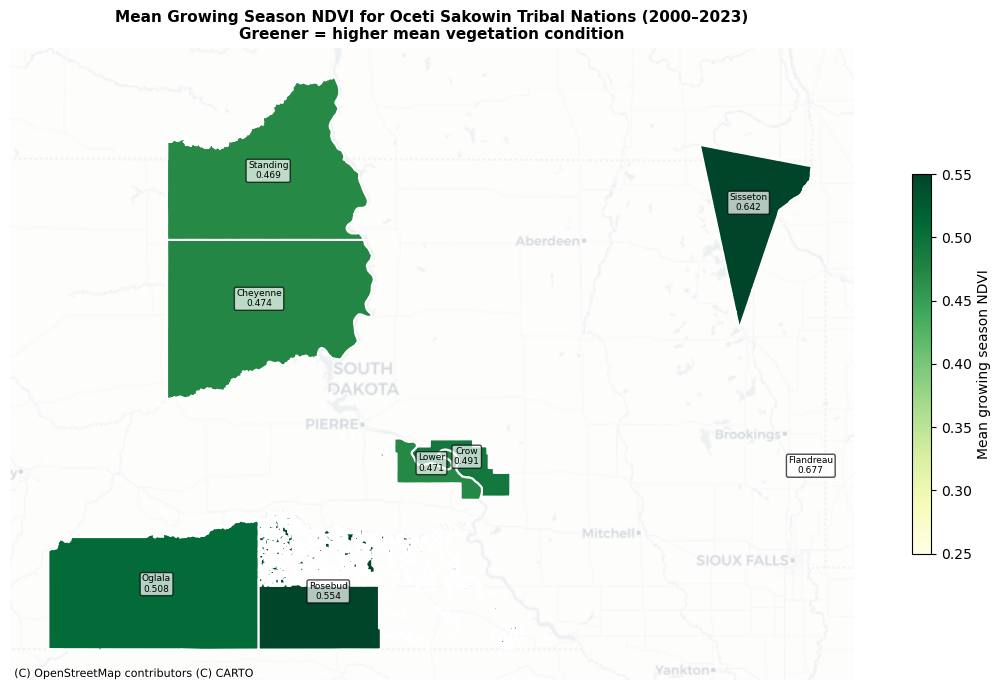

In [38]:
# Choropleth map: mean NDVI by Tribal Nation
fig, ax = plt.subplots(figsize=(12, 7))

sd_tribes.to_crs(3857).plot(
    column="mean_ndvi",
    cmap="YlGn",
    vmin=0.25, vmax=0.55,
    ax=ax,
    edgecolor="white",
    linewidth=1.5,
    legend=True,
    legend_kwds={"label": "Mean growing season NDVI", "shrink": 0.6},
    missing_kwds={"color": "lightgray"},
)

# Label each Tribal land
for _, row in sd_tribes.iterrows():
    if pd.notna(row.get("mean_ndvi")):
        c = row.geometry.centroid
        c3857 = gpd.GeoDataFrame(
            geometry=[c], crs="EPSG:4326"
        ).to_crs(3857).geometry.iloc[0]
        name_short = row["common_name"].split()[0]
        ax.annotate(
            f"{name_short}\n{row['mean_ndvi']:.3f}",
            (c3857.x, c3857.y),
            ha="center", fontsize=6.5,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7),
        )

try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, alpha=0.4)
except Exception:
    pass

ax.set_axis_off()
ax.set_title(
    "Mean Growing Season NDVI for Oceti Sakowin Tribal Nations (2000–2023)\n"
    "Greener = higher mean vegetation condition",
    fontsize=11, fontweight="bold",
)
plt.tight_layout()
plt.show()

## Summary: Spatial Operations

| Operation | rioxarray method | What it does |
|---|---|---|
| Assign CRS | `.rio.write_crs("EPSG:4326")` | Tell the cube what coordinate system it's in |
| Set spatial dims | `.rio.set_spatial_dims(x_dim, y_dim)` | Tell rioxarray which dims are spatial |
| Clip | `.rio.clip(geometry, crs=...)` | Cut to a bounding polygon |
| Reproject | `.rio.reproject("EPSG:5070")` | Change coordinate system |
| Get bounds | `.rio.bounds()` | Spatial extent of the array |
| Get resolution | `.rio.resolution()` | Pixel size |

## Discussion Questions
1. The coarse 0.5° grid in this notebook has only a few pixels covering
   Pine Ridge. What grid spacing would you need to see meaningful spatial
   variation within the reservation? What are the tradeoffs with using
   a finer grid?

2. The choropleth map shows mean NDVI by Oceti Sakowin Nation. What factors
   might explain differences between Nations, is it climate? Land management?
   Vegetation type? How would you investigate which factor is most important?

3. The Pine Ridge boundary used here comes from the Census Bureau.
   The Census defines boundaries for statistical purposes. What are the
   implications of using Census-defined boundaries for environmental
   analysis on Tribal lands? How might the Oglala Lakota Nation define
   their own territorial boundary differently?

## Next Notebook
**06 Analysis Patterns:** Anomalies, trends, and composites:
the analytical techniques that turn a data cube into environmental
insights.